Summary Statistics:


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-25 12:00:30.000000768,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
min,2021-10-25 00:01:00,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,2022-01-24 06:00:45,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2022-04-25 12:00:30,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,2022-07-25 18:00:15,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,2022-10-25 00:00:00,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN
std,NaN,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN


Missing Value Report:


,Missing Count,Missing %
Comments,525600,100.0


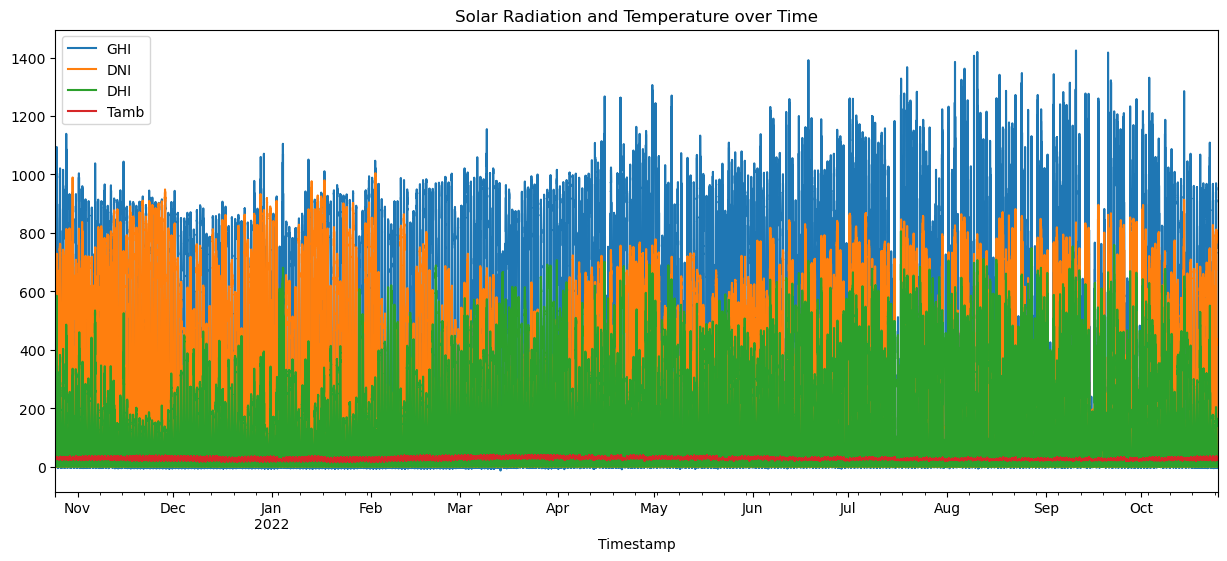

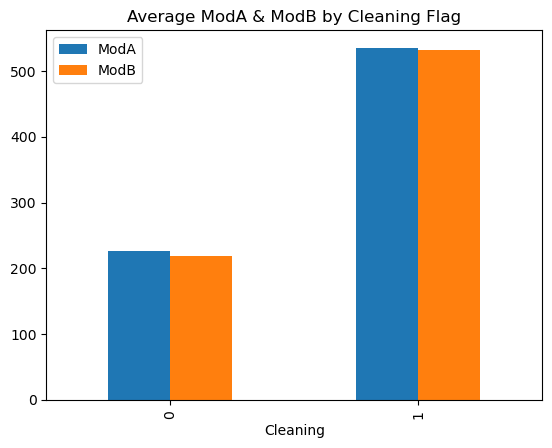

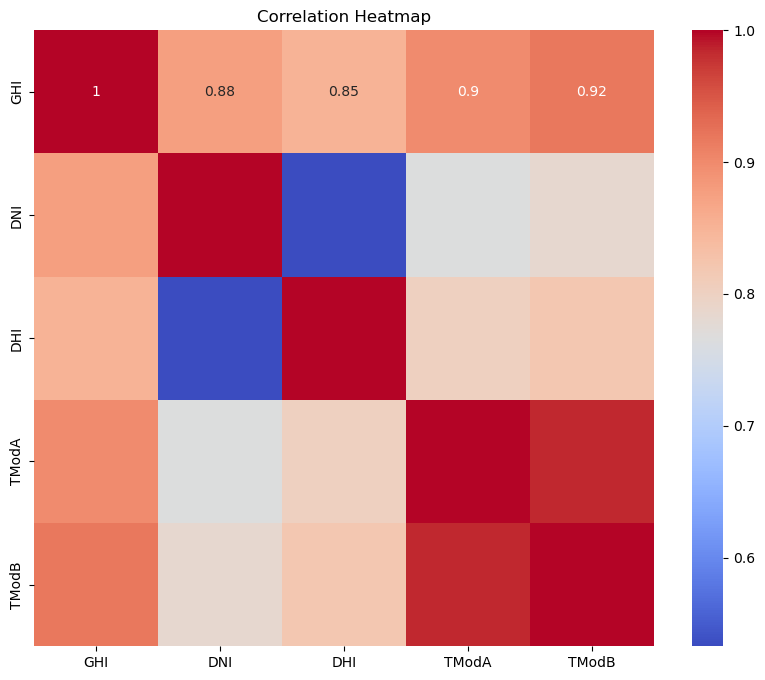

In [3]:
# togo-dapaong_qc_eda.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import os

# Load Data
df = pd.read_csv("../../data/togo-dapaong_qc.csv", parse_dates=["Timestamp"])

# Summary Statistics
print("Summary Statistics:")
display(df.describe())

# Missing Value Report
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print("Missing Value Report:")
display(missing_report[missing_report['Missing %'] > 5])

# Outlier Detection (Z-score)
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = df[cols_to_check].apply(zscore)
df['outlier'] = (np.abs(z_scores) > 3).any(axis=1)

# Impute missing values in key columns
for col in cols_to_check:
    df[col].fillna(df[col].median(), inplace=True)

# Drop rows with missing values in essential non-sensor columns
essential_cols = ['Tamb', 'RH', 'WD', 'BP']
df_clean = df.dropna(subset=essential_cols)

# Save cleaned file
output_path = "../../data/togo_clean.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_clean.to_csv(output_path, index=False)

# ---- Visualizations ----

# Time Series
df_clean.set_index("Timestamp")[['GHI', 'DNI', 'DHI', 'Tamb']].plot(figsize=(15, 6), title="Solar Radiation and Temperature over Time")
plt.show()

# Cleaning Impact
df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar', title='Average ModA & ModB by Cleaning Flag')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



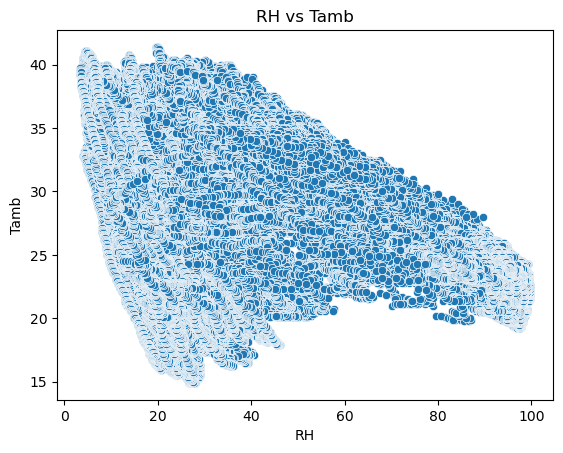

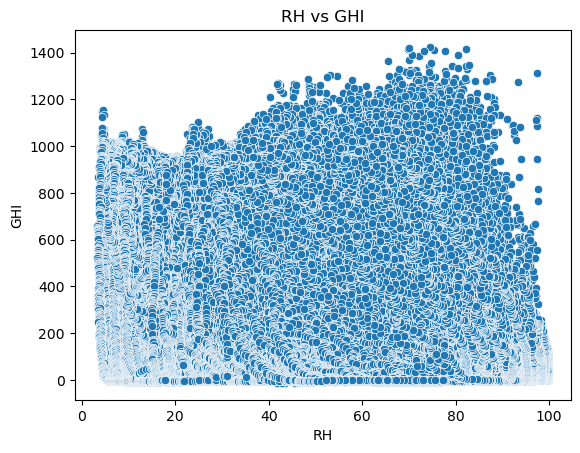

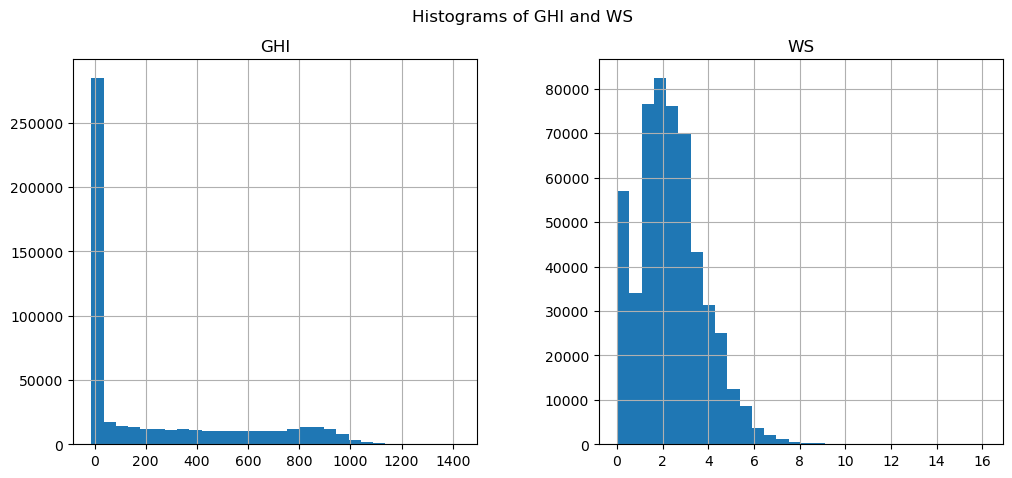

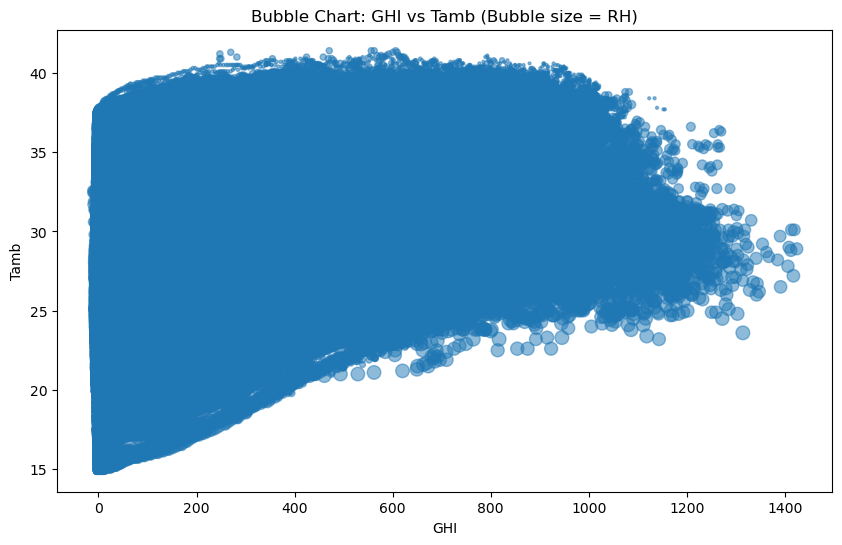

In [2]:
# Scatter Plots
#sns.pairplot(df_clean, vars=['WS', 'WSgust', 'WD'], hue='GHI')
#plt.suptitle("Wind Variables vs GHI", y=1.02)
#plt.show()

# RH vs Tamb & GHI
sns.scatterplot(data=df_clean, x='RH', y='Tamb')
plt.title("RH vs Tamb")
plt.show()

sns.scatterplot(data=df_clean, x='RH', y='GHI')
plt.title("RH vs GHI")
plt.show()

# Histogram
df_clean[['GHI', 'WS']].hist(bins=30, figsize=(12, 5))
plt.suptitle("Histograms of GHI and WS")
plt.show()

# Bubble Chart
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['GHI'], df_clean['Tamb'], s=df_clean['RH'], alpha=0.5)
plt.xlabel("GHI")
plt.ylabel("Tamb")
plt.title("Bubble Chart: GHI vs Tamb (Bubble size = RH)")
plt.show()
